Loading all training snapshots (20k+)...
Computing Vector POD on full training set...
Sweeping mode counts for 1% and 5% thresholds...


100%|██████████| 1024/1024 [22:27<00:00,  1.32s/it]


Threshold       | Modes (u)    | Modes (v)   
---------------------------------------------
       5.0% Error | 178          | 145         
       1.0% Error | 548          | 462         


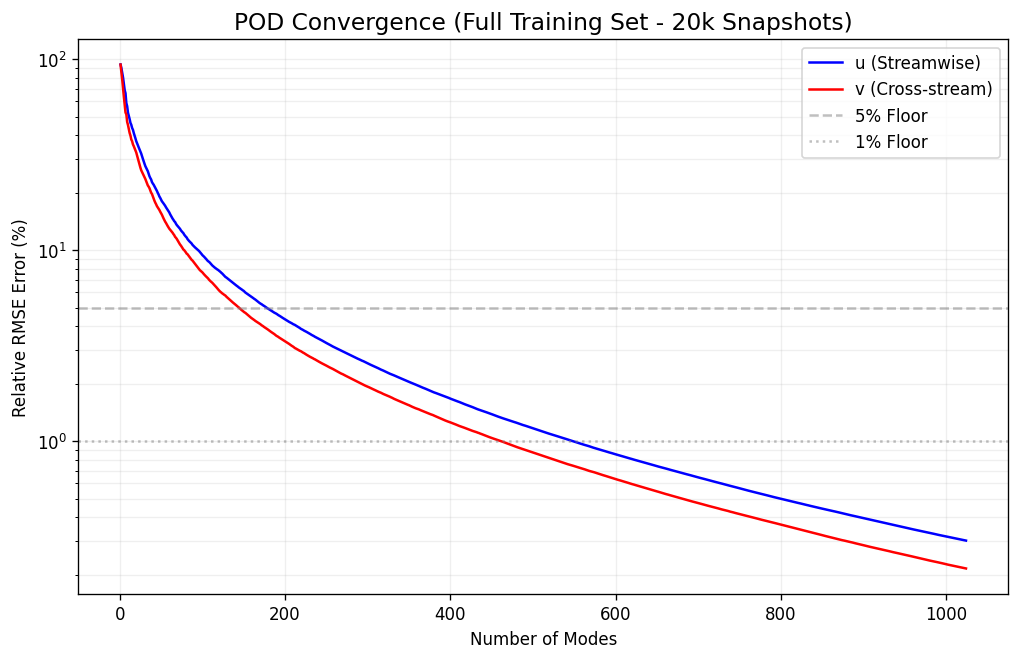

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm

# --- 1. Configuration ---
output_dir = "/media/chris-remote/Projects/ONeill/estimation/output/kevin_2cylinder"
unified_h5 = os.path.join(output_dir, "flipflop_velocity_unified.h5")

# --- 2. Load Full Training Data (No Stride) ---
print("Loading all training snapshots (20k+)...")
with h5py.File(unified_h5, 'r') as f:
    ux = f['train/ux'][:]
    uy = f['train/uy'][:]

# Compute Fluctuations
ux_mean, uy_mean = np.mean(ux, axis=0), np.mean(uy, axis=0)
ux_prime, uy_prime = ux - ux_mean, uy - uy_mean

# Denominators for Relative RMSE
total_var_u = np.mean(ux_prime**2)
total_var_v = np.mean(uy_prime**2)

# --- 3. Full-Field Vector POD ---
print("Computing Vector POD on full training set...")
S = np.hstack([ux_prime, uy_prime])

# We'll calculate 1024 modes to find the 1% and 5% thresholds
n_modes_max = 1024
pca = PCA(n_components=n_modes_max, svd_solver='randomized', random_state=42)
coeffs = pca.fit_transform(S)  # (N_time, n_modes)
phi = pca.components_          # (n_modes, 2*N_points)

n_pts = ux.shape[1]
phi_u, phi_v = phi[:, :n_pts], phi[:, n_pts:]

# --- 4. Incremental Error Sweep ---
print("Sweeping mode counts for 1% and 5% thresholds...")
thresholds = [0.05, 0.01] # 5%, 1%
required_modes = {t: {'u': None, 'v': None} for t in thresholds}

# To save RAM, we use the property that reconstruction is additive
u_recon = np.zeros_like(ux_prime)
v_recon = np.zeros_like(uy_prime)
err_u_hist, err_v_hist = [], []

for n in tqdm(range(n_modes_max)):
    # Reconstruction contribution of mode n
    u_recon += np.outer(coeffs[:, n], phi_u[n, :])
    v_recon += np.outer(coeffs[:, n], phi_v[n, :])
    
    # Relative RMS Error: sqrt(mean((true-recon)^2) / mean(true^2))
    err_u = np.sqrt(np.mean((ux_prime - u_recon)**2) / total_var_u)
    err_v = np.sqrt(np.mean((uy_prime - v_recon)**2) / total_var_v)
    
    err_u_hist.append(err_u)
    err_v_hist.append(err_v)
    
    for t in thresholds:
        if required_modes[t]['u'] is None and err_u <= t:
            required_modes[t]['u'] = n + 1
        if required_modes[t]['v'] is None and err_v <= t:
            required_modes[t]['v'] = n + 1

# --- 5. Report & Plot ---
print("\n" + "="*45)
print(f"{'Threshold':<15} | {'Modes (u)':<12} | {'Modes (v)':<12}")
print("-" * 45)
for t in thresholds:
    mu = required_modes[t]['u']
    mv = required_modes[t]['v']
    print(f"{t*100:>10.1f}% Error | {str(mu):<12} | {str(mv):<12}")
print("="*45)

plt.figure(figsize=(10, 6), dpi=120)
plt.plot(range(1, n_modes_max+1), np.array(err_u_hist)*100, label='u (Streamwise)', color='blue')
plt.plot(range(1, n_modes_max+1), np.array(err_v_hist)*100, label='v (Cross-stream)', color='red')
plt.axhline(5, color='gray', ls='--', alpha=0.5, label='5% Floor')
plt.axhline(1, color='gray', ls=':', alpha=0.5, label='1% Floor')
plt.yscale('log')
plt.title("POD Convergence (Full Training Set - 20k Snapshots)", fontsize=14)
plt.xlabel("Number of Modes")
plt.ylabel("Relative RMSE Error (%)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()